# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Ansen Halim
- **Email:** cdcc467d6y2296@student.devacademy.id
- **ID Dicoding:** CDCC467D6Y2296

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana perbedaan pola jumlah penyewaan sepeda per jam antara hari kerja (*working day*) dan hari libur (*holiday*) selama tahun 2012 untuk menentukan efisiensi jadwal pemeliharaan?

- **Pertanyaan 2:** Berapa persentase pertumbuhan pengguna terdaftar (*registered*) dibandingkan pengguna biasa (*casual*) pada setiap musim di tahun 2012 dibandingkan tahun 2011 untuk mengevaluasi loyalitas pelanggan?

- **Pertanyaan 3:** Sejauh mana penurunan jumlah total penyewaan sepeda terjadi saat kondisi cuaca buruk (hujan/salju) dibandingkan cuaca cerah di sepanjang periode 2011-2012 untuk keperluan manajemen risiko operasional?

## Import Semua Packages/Library yang Digunakan

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load Dataset day_df dan hour_df

In [21]:
#Memuat tabel day_df
day_df = pd.read_csv('day.csv')

#Memuat tabel hour_df
hour_df = pd.read_csv('hour.csv')

#Menampilkan 5 baris pertama dari tabel day
print("Data Harian (day_df):")
print(day_df.head())

print("\n" + "="*50 + "\n")

#Menampilkan 5 baris pertama dari tabel hour
print("Data Per Jam (hour_df):")
print(hour_df.head())

Data Harian (day_df):
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  


Da

**Insight:** (Opsional)
- Seluruh data dari kedua berkas .csv telah berhasil di-load ke dalam *DataFrame*. Berdasarkan tampilan awal, data memiliki struktur yang konsisten dan kolom yang lengkap sesuai dokumentasi dataset.
- Fitur-fitur yang dimuat dari kedua dasaset lengkap, mencakup informasi temporal (tanggal, musim, jam), kondisi lingkungan (suhu, kelembapan, kecepatan angin), serta data target berupa penyewaan (*cnt*).
- Fitur-fitur numerik seperti **temp, atemp, hum, dan windspeed** sudah dinormalisasi dalam bentuk skala 0 hingga 1.

### Assessing Data

#### Identifying missing, duplicates, outliers, and inconsistent values problem

In [22]:
#1. Mengecek missing values
print("### Missing Values - day_df ###")
print(day_df.isna().sum())
print("\n### Missing Values - hour_df ###")
print(hour_df.isna().sum())

#2. Mengecek duplicate values
print("\n" + "="*50)
print("Jumlah duplikasi day_df", day_df.duplicated().sum())
print("Jumlah duplikasi hour_df", hour_df.duplicated().sum())

#3. Mengecek outliers
print("\n" + "="*50)
print("### Outliers - day_df ###")
print(day_df.describe())
print("\n### Outliers - hour_df ###")
print(hour_df.describe())

#4. Mengecek inconsistent daya types
print("\n" + "="*50)
print("### Data Types - day_df ###")
print(day_df.info)
print("\n### Data Types - hour_df ###")
print(hour_df.info)

### Missing Values - day_df ###
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

### Missing Values - hour_df ###
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Jumlah duplikasi day_df 0
Jumlah duplikasi hour_df 0

### Outliers - day_df ###
          instant      season          yr        mnth     holiday     weekday  \
count  731.000000  731.000000  731.000000  731.000000  731.000000  731.000000   
mean   366.000000    2.496580    0.500684    6.519836    0.028728    2.997264   
std    211.165812    1.110807    0.500342    3.451913   

**Steps to Take:**
- Mengubah kolom **dteday** pada *day_df* dan *hour_df* dari tipe data *object* menjadi tipe data *datetime* agar analisis berbasis waktu dapat berjalan dengan benar.
- Memperbaiki nilai 0.0 pada kolom **hum** di kedua dataset dengan nilai rata-rata dari masing-masing dataset.
- Mengubah representasi angka pada kolom **season** (1-4) dan **weathersit** menjadi label teks yang lebih bermakna.
- Memastikan kolom-kolom lainnya tetap dalam format yang konsisten digunakan sebagai variabel *grouping* pada tahap EDA.

**Insight:** (Opsional)
- Pada dataset day_df, ditemukan outlier pada kolom **hum** (humidity) dengan nilai minimum 0.0, secara praktis tidak mungkin terjadi pada kondisi atmosfer yang normal.
- Kolom **dteday** pada day_df terdeteksi sebagai data bertipe *object*. Kolom harus dikonversi menjadi *datetime* agar proses analisis berbasis waktu dapat secara akurat dilakukan
- Ditemukan juga nilai **hum** (humidity) pada hour_df sebesar 0.00 yang kurang masuk akal. Hal ini akan diperbaiki dengan *mean imputation* pada tahap *cleaning*.
- Terdapat lonjakan penyewaan pada dataset hour_df hingga 977 sepeda per jam. Meskipun secara statistik termasuk outlier, data ini masih dianggap valid karena merepresentasikan kondisi *peak/high demand*.
- Variabel kategori berupa angka (1,2,3...) yang akan menyulitkan interpretasi secara visual.

### Cleaning Data

#### Fixing problems

In [23]:
#1. Konversi tipe data 'dteday' menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

#2. Menangani inconsistent valus pada kolom hum (humidity) dengan nilai mean masing-masing dataset
day_df['hum'] = day_df['hum'].replace(0, day_df['hum'].mean())
hour_df['hum'] = hour_df['hum'].replace(0, hour_df['hum'].mean())

#3. Mapping label kategori agar lebih intuitif (Season & Weather)
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_mapping = {
    1: 'Clear',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Ice'
}

#Terapkan mapping pada day_df
day_df['season'] = day_df['season'].map(season_mapping)
day_df['weathersit'] = day_df['weathersit'].map(weather_mapping)

#Terapkan mapping pada hour_df
hour_df['season'] = hour_df['season'].map(season_mapping)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_mapping)

#VERIFIKASI
print('### Hasil Pembersihan Data ###')
print(f"Tipe data 'dteday' sekarang: {day_df['dteday'].dtype}")
print(f"Nilai minimum kelembapan (hum): {day_df['hum'].min():.4f}")
print(f"Kategori Season: {day_df['season'].unique()}")
print(f"Kategori Weather: {day_df['weathersit'].unique()}")

#Menampilkan 5 data teratas setelah dibersihkan
day_df.head()
hour_df.head()


### Hasil Pembersihan Data ###
Tipe data 'dteday' sekarang: datetime64[ns]
Nilai minimum kelembapan (hum): 0.1879
Kategori Season: ['Spring' 'Summer' 'Fall' 'Winter']
Kategori Weather: ['Misty/Cloudy' 'Clear' 'Light Snow/Rain']


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,1,0,0,6,0,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,0,1,1,0,6,0,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,0,1,2,0,6,0,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,0,1,3,0,6,0,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,0,1,4,0,6,0,Clear,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Dengan mengganti nilai kelambapan 0% menjadi nilai *mean*, kita dapat memastikan bahwa hasil analisis korelasi nantinya tidak akan terdistorsi oleh kesalahan sensor
- Konversi kolom **dteday** memastikan dataset siap digunakan *time series analysis* guna melihat tren penyewaan dari waktu ke waktu.
- Transformasi kode numerik menjadi label kategorikal (seperti nama musim dan kondisi cuaca) akan sangat mempermudah proses komunikasi hasil temuan kepada pemangku kepentingan karena data sudah berbicara dalam bahasa yang manusiawi.

## Exploratory Data Analysis (EDA)

### Explore General Parameter Statistics

In [24]:
#Melihat rangkuman parameter statistik untuk data harian
print("Statistik Deskriptif day_df:")
display(day_df.describe(include="all"))

#Melihat rangkuman parameter statistik untuk data per jam
print("\nStatistik Deskriptif hour_df:")
display(hour_df.describe(include="all"))

Statistik Deskriptif day_df:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731,731.000000,731.000000,731.000000,731.000000,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,NaN,NaN,NaN,NaN,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,188,NaN,NaN,NaN,NaN,NaN,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,NaN,0.500684,6.519836,0.028728,2.997264,0.683995,NaN,0.495385,0.474354,0.628753,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,NaN,0.000000,1.000000,0.000000,0.000000,0.000000,NaN,0.059130,0.079070,0.187917,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,NaN,0.000000,4.000000,0.000000,1.000000,0.000000,NaN,0.337083,0.337842,0.521041,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,NaN,1.000000,7.000000,0.000000,3.000000,1.000000,NaN,0.498333,0.486733,0.627500,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,NaN,1.000000,10.000000,0.000000,5.000000,1.000000,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,NaN,1.000000,12.000000,1.000000,6.000000,1.000000,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000



Statistik Deskriptif hour_df:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,NaN,NaN,NaN,NaN,NaN,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496,NaN,NaN,NaN,NaN,NaN,NaN,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,NaN,0.496987,0.475775,0.628023,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.020000,0.000000,0.080000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight day_df:** (Opsional)
- Dari dataset day_df, rata-rata penyewaan harian mencapai 4,504 unit dengan nilai maksomum 8,714 unit.
- Peak season terdapat pada musim gugur karena sering muncul dalam pencatatan.
- Mayoritas hari memilik cuaca **Clear**, menunjukkan bisnis penyewaan sepeda sangat bergantung pada cuaca yang mendukung.

**Insight hour_df:** (Opsional)
- Variabilitas perbedaan penyewaan per jam cukup tinggi, dengan nilai rata-rata 189 unit dan nilai maksimum mencapai 977 unit.
- Kondisi cuaca **Clear** mendominasi, 11,413 jam dari total 17,379 jam.
- Standar deviasi pada kolom **cnt** mencapai 181 menunjukkan nilai fluktuasi per jam yang sangat besar.


### Explore Business Questions

In [25]:
#Pertanyaan 1: Analisis Pola Jam Sibuk
#Mengelompokkan penyewaan berdasarkan hari kerja dan jam
hr_workingday_analysis = hour_df.groupby(by=["workingday", "hr"]).agg({
    "cnt": ["mean", "max", "min"]
})
print("Analisis Penyewaan per Jam (Hari Kerja vs Hari Libur):")
display(hr_workingday_analysis)

#Pertanyaan 2: Analisis Pertumbuhan Berdasarkan Musim
#Mengelompokkan berdasarkan musim
season_analysis = day_df.groupby(by="season").agg({
    "casual": "sum",
    "registered": "sum",
    "cnt": "sum"
}).sort_values(by="cnt", ascending=False)

print("Analisis Penyewaaan berdasarkan Musim:")
display(season_analysis)

#Pertanyaan 3: Analisis Dampak Cuaca
#Mengelompokkan berdasarkan kondisi cuaca
weather_analysis = day_df.groupby(by="weathersit").agg({
    "cnt": ["mean", "max", "min", "std"]
})

print("Analisis Dampak Cuaca terhadap Jumlah Penyewaan:")
display(weather_analysis)

Analisis Penyewaan per Jam (Hari Kerja vs Hari Libur):


cnt         
                     mean  max min
workingday hr                     
0          0    90.800000  249   6
           1    69.508696  168   4
           2    53.171053  132   2
           3    25.775330   79   2
           4     8.264317   28   1
           5     8.689189   55   1
           6    18.742358  133   1
           7    43.406926  387   1
           8   105.653680  597   5
           9   171.623377  397  14
           10  255.909091  539  12
           11  315.316017  663  27
           12  366.259740  776  32
           13  372.731602  760  30
           14  364.645022  750  23
           15  358.813853  750   7
           16  352.727273  783  11
           17  323.549784  731  15
           18  281.056522  676  23
           19  231.673913  554  11
           20  174.739130  551  11
           21  142.060870  584   7
           22  116.060870  502   9
           23   85.930435  239   2
1          0    36.786290  283   2
           1    16.552632  114   1
           2     8.683778   74   1
           3     4.942553   36   1
           4     5.429787   17   1
           5    24.913131   66   1
           6   102.500000  213   7
           7   290.612903  596  18
           8   477.006048  839  31
           9   241.518145  426  23
           10  135.366935  275   8
           11  158.229839  361  10
           12  200.820926  471   3
           13  198.429719  428  11
           14  183.572289  651  12
           15  201.331325  601  13
           16  293.122244  634  13
           17  525.290581  976  26
           18  492.226908  977  26
           19  348.401606  743  18
           20  249.718876  567  23
           21  186.287149  398   6
           22  138.389558  321  11
           23   88.708835  256   9

Analisis Penyewaaan berdasarkan Musim:


,casual,registered,cnt
season,,,
Fall,226091,835038,1061129
Summer,203522,715067,918589
Winter,129782,711831,841613
Spring,60622,410726,471348


Analisis Dampak Cuaca terhadap Jumlah Penyewaan:


cnt                        
                        mean   max  min          std
weathersit                                          
Clear            4876.786177  8714  431  1879.483989
Light Snow/Rain  1803.285714  4639   22  1240.284449
Misty/Cloudy     4035.862348  8362  605  1809.109918

**Insight Pertanyaan 1:** (Opsional)
- Terdapat perbedaan signifikan dalam jam sibuk antara hari kerja dan hari libur. Pada hari kerja, manajemen harus memastikan ketersediaan sepeda maksimal pada pukul 08:00 dan 17:00.
- Waktu terbaik untuk melakukan pengecekan atau perbaikan sepeda pada hari kerja adalah pukul 10:00 hingga 15:00 (saat permintaan turun), sedangkan pada hari libur, pemeliharaan sebaiknya dilakukan di pagi hari sebelum pukul 09:00.
- Strategi pada hari kerja harus difokuskan pada fungsionalitas (kecepatan akses bagi komuter), sedangkan pada hari libur bisa difokuskan pada promosi tempat wisata atau rute santai.

**Insight Pertanyaan 2:** (Opsional)
- Manajemen perlu mengalokasikan sumber daya dan stok sepeda paling banyak pada musim Fall dan Summber. Sebaliknya, musim Spring bisa digunakan untuk melakukan perawatan besar-besaran (*big maintenance*) karena permintaan sedang rendah.
- Terdapat lonjakan pengguna *Casual* yang signifikan pada musim panas dan gugur. Perusahaan dapat meluncurkan kampanye "Membership Summer Pass" untuk mendorong pengguna *casual* beralih menjadi *registered* user.
- Rasio pengguna terdaftar yang konsisten tinggi di semua musim membuktikan bahwa layanan ini sudah menjadi kebutuhan mobilitas utama (komuter), bukan sekadar hobi musiman.

**Insight Pertanyaan 3:** (Opsional)
- Cuaca buruk (*Light Snow/Rain*) merupakan faktor risiko utama yang menyebabkan penurunan drastis pendapatan. Perusahaan perlu mempertimbangkan strategi diversifikasi atau promo khusus "Indoor Activity" jika memiliki unit bisnis lain saat cuaca buruk diprediksi terjadi.
- Pada kondisi *Clear*, perusahaan harus memastikan seluruh armada sepeda dalam kondisi siap pakai karena beban kerja sistem berada pada titik maksimal.
- Menarik untuk dicatat bahwa kategori **"Heavy Rain/Ice"** (kategori 4) tidak muncul dalam hasil agregasi harian ini. Hal ini mengonfirmasi temuan kita saat *Assessing Data* bahwa tidak ada data harian dengan rata-rata cuaca ekstrem, atau kemungkinan besar sistem berhenti beroperasi sepenuhnya demi keselamatan saat cuaca sangat buruk.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perbedaan pola jumlah penyewaan sepeda per jam antara hari kerja (working day) dan hari libur (holiday) selama tahun 2012 untuk menentukan efisiensi jadwal pemeliharaan?

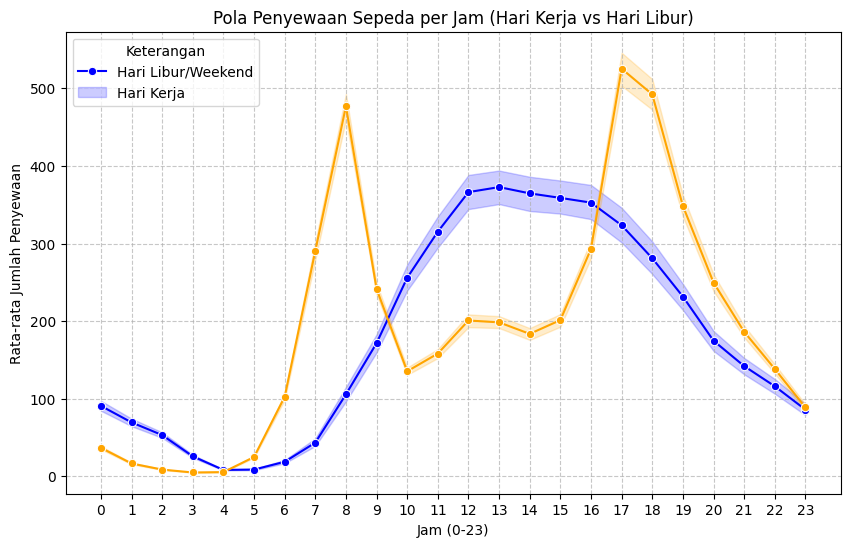

In [26]:
plt.figure(figsize=(10,6))
sns.lineplot(data=hour_df, x='hr', y='cnt', hue='workingday', marker='o', palette={0:'blue', 1: 'orange'})

plt.title('Pola Penyewaan Sepeda per Jam (Hari Kerja vs Hari Libur)')
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.legend(title='Keterangan', labels=['Hari Libur/Weekend', 'Hari Kerja'])
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Pertanyaan 2: Berapa persentase pertumbuhan pengguna terdaftar (registered) dibandingkan pengguna biasa (casual) pada setiap musim di tahun 2012 dibandingkan tahun 2011 untuk mengevaluasi loyalitas pelanggan?

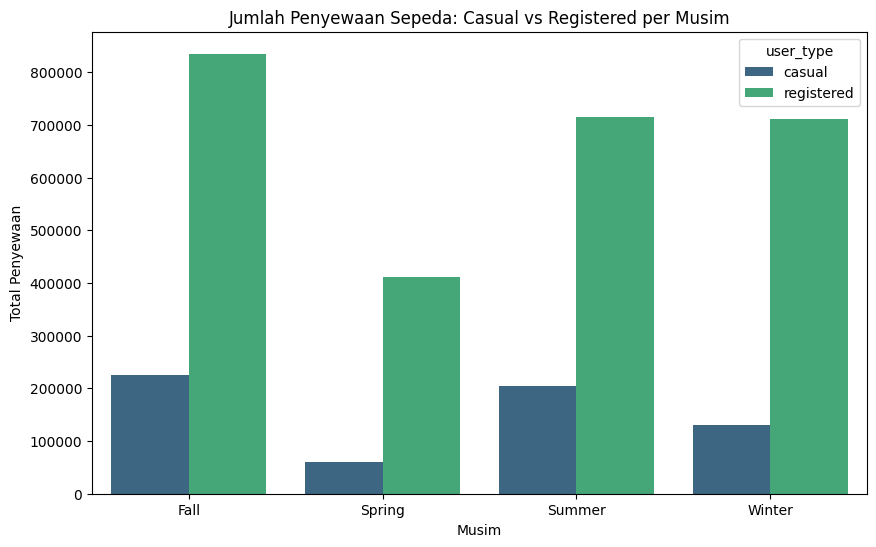

In [27]:
#Menyiapkan data untuk bar chart
season_rentals = day_df.groupby('season')[['casual', 'registered']].sum().reset_index()
season_melted = pd.melt(season_rentals, id_vars=['season'], value_vars=['casual', 'registered'],
                        var_name='user_type', value_name='total_rentals')

plt.figure(figsize=(10,6))
sns.barplot(data=season_melted, x='season', y='total_rentals', hue='user_type', palette='viridis')

plt.title('Jumlah Penyewaan Sepeda: Casual vs Registered per Musim')
plt.xlabel('Musim')
plt.ylabel('Total Penyewaan')
plt.show()

### Pertanyaan 3: Sejauh mana penurunan jumlah total penyewaan sepeda terjadi saat kondisi cuaca buruk (hujan/salju) dibandingkan cuaca cerah di sepanjang periode 2011-2012 untuk keperluan manajemen risiko operasional?

/tmp/ipykernel_4147/2645658717.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weather_rentals, x='weathersit', y='cnt', palette='magma')


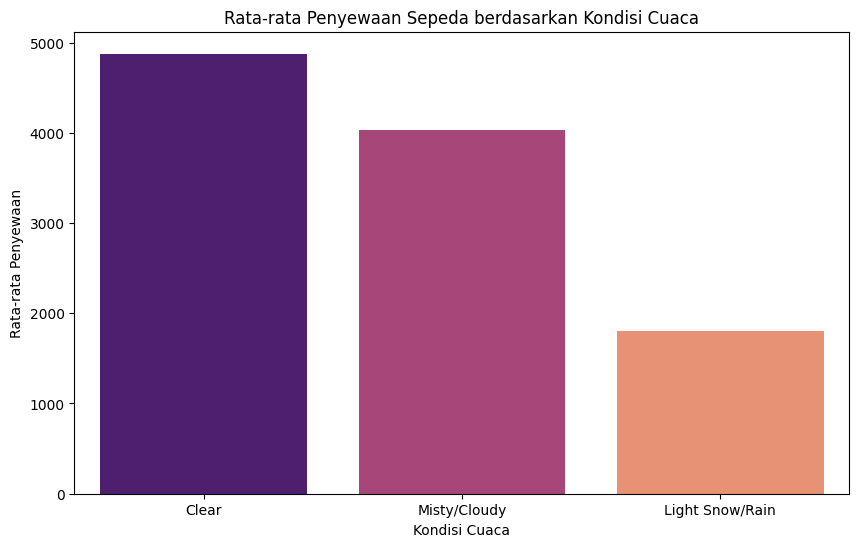

In [28]:
weather_rentals = day_df.groupby('weathersit')['cnt'].mean().reset_index().sort_values(by='cnt', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=weather_rentals, x='weathersit', y='cnt', palette='magma')

plt.title('Rata-rata Penyewaan Sepeda berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

**Insight Grafik Pola Penyewaan Sepeda per Jam (Grafik 1):** (Opsional)

Grafik menunjukkan fenomena **"Double Peak"** pada hari kerja (pukul 08:00 dan 17:00) yang kontras dengan pola **"Bell Curve"** pada hari libur. Arus penyewaan di hari kerja terkonsentrasi pada jam produktif, sementara hari libur menunjukkan aktivitas yang lebih santai di tengah hari.

**Insight Grafik Jumlah Penyewaan Sepeda per Musim (Grafik 2):** (Opsional)

Terlihat bahwa musim Gugur **(Fall)** adalah kontributor pendapatan terbesar. Secara struktural, **Registered Users** merupakan fondasi bisnis yang stabil di setiap musim, sedangkan **Casual Users** adalah segmen yang sangat fluktuatif dan hanya melonjak pada musim-musim bertemperatur hangat.

**Insight Grafik Rata-rata Penyewaan Sepeda berdasarkan Kondisi Cuaca (Grafik 3):** (Opsional)

Visualisasi menunjukkan korelasi negatif yang kuat antara presipitasi dan jumlah penyewaan. Terdapat penurunan drastis lebih dari 60% saat kondisi cuaca berubah dari **Clear** menjadi **Light Snow/Rain**. Cuaca cerah adalah pendorong utama volume transaksi.

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1: Pola Penyewaan per Jam (Hari Kerja vs Hari Libur)**

  Pola penggunaan sepeda didorong oleh **kebutuhan mobilitas fungsional** pada hari kerja (komuter) dan **kebutuhan rekreasi** pada hari libur. Bisnis ini berfungsi sebagai infrastruktur transportasi utama bagi pekerja di jam sibuk pagi dan jam pulang sore hari.

- **Conclusion pertanyaan 2: Jumlah Penyewaan Sepeda (Casual vs Registered) per Musim**

  Stabilitas bisnis sangat bergantung pada **basis pelanggan terdaftar (Registered)** yang tetap aktif di musim dingin sekalipun. Namun, potensi lonjakan profitabilitas tertinggi berada di **Musim Gugur**, dimana kedua segmen pengguna, *Casual & Registered* mencapai titik penggunaan maksimal secara bersamaan.

- **Conclusion pertanyaan 3: Rata-rata Penyewaan Sepeda berdasarkan Kondisi Cuaca**

  Kondisi cuaca adalah **variabel risiko eksternal terbesar**. Bisnis penyewaan sepeda ini memiliki tingkat sensitivitas yang tinggi terhadap cuaca buruk, dimana hujan atau salju ringan dapat memlumpuhkan lebih dari setengah aktivitas harian pengguna.

**Rekomendasi Action Item:**
- Untuk menjawab **pertanyaan 1**, waktu yang tepat dan efisien untuk melakukan perawatan sepeda sebaiknya selesai sebelum pukul 07:00 dan 16:00 pada hari kerja untuk menangkap permintaan tinggi dari para komuter.

- Untuk **pertanyaan 2**, bisnis dapat melakukan kampanye konversi keanggotaan (*membership*) pada akhir musim panas menuju **Musim Gugur** untuk mendorong pengguna *Casual* yang sedang aktif-aktifnya agar beralih menjadi pengguna *Registered*.

- Untuk **pertanyaan 3**, bisnis juga dapat memberikan promo khusus seperti "Rainy Day Voucher" yang bisa digunakan di hari berikutnya jika terjadi hujan, untuk menjaga loyalitas pelanggan agar tetap kembali menggunakan layanan meskipun frekuensi penggunaan turun saat cuaca buruk.

- Kemudian berkaitan dengan *maintenance*, bisnis dapat melakukan perbaikan sistem pada **Musim Semi (Spring)** atau pada pukul **10:00-15:00** di hari kerja, karena pada waktu-waktu tersebut tingkat permintaan berada di titik terendah.

In [30]:
main_data = hour_df.copy()
main_data.to_csv('main_data.csv', index=False)

from google.colab import files
files.download('main_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>